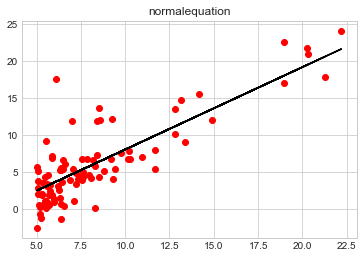

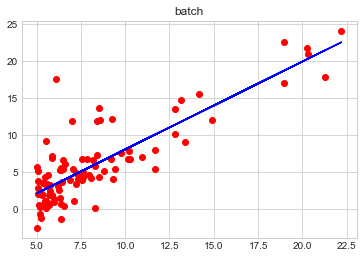

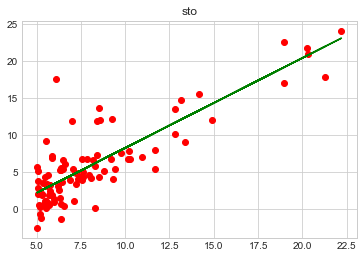

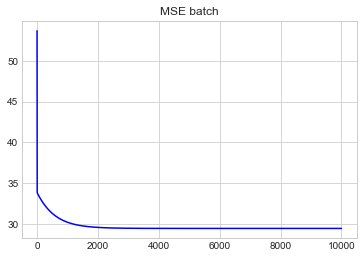

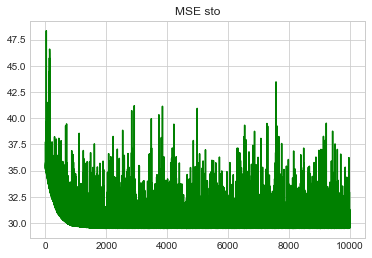

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import math

plt.style.use('seaborn-whitegrid') 

def Read():
    fi=pd.read_csv('data2.txt',header=None)
    fi=fi.values
    fi=np.split(fi, 2, axis=1)
    x=fi[0].T
    y=fi[1].T
    x=x.reshape(x.size,1)
    y=y.reshape(y.size,1)
    
    return x,y

def normalEqui(x,y,deg):
    plt.figure(1)
    plt.title("normalequation")
    plt.plot(x,y,"ro")
    l=4
    xn=x.reshape(x.size)
    yn=y.reshape(y.size)
    deg=deg+1
    i=np.identity(deg)
    xm=np.full([x.size,1],1.0)
    for f in range(deg-1):
       xm=np.insert(xm,0,values=np.power(xn,f+1),axis=1)
    w=np.dot(np.linalg.inv(l*i+np.dot(xm.T,xm)),np.dot(xm.T,y))
    i=0
    y1=np.polyval(w,x)
    plt.plot(xn.reshape(xn.size,1),y1,"black")

    return w

def mCo(x,deg):
    xm=np.ones((x.size,1))
    for i in range (deg):
    xm=np.append(xm,x,axis=1)#values=np.power(x,f+1)
    return xm



def sto(x,y):
    plt.figure(3)
    plt.title("sto")
    plt.plot(x,y,"ro")
    X=mCo(x,1)
    Y=y
    loop_max = 10000
    theta = np.random.rand(2,1)
    batch_size = 10
    epsilon = 25
    learning_rate = 0.01
    j=np.zeros(loop_max)
    zz=loop_max
    for i in range(loop_max):
        idxs = np.random.randint(0,X.shape[0],size=batch_size)
        tmp_X = X.take(idxs,axis=0)
        tmp_y = y.take(idxs,axis=0)
        grad = np.dot(tmp_X.T, (np.dot(tmp_X, theta) - tmp_y))/batch_size
        theta = theta - learning_rate*grad
        j[i] = np.linalg.norm(np.dot(X,theta)-y)
        if j[i] < epsilon:
            print("ok")
            zz=i
            break
   #print(theta)
    plt.plot(x,X.dot(theta),"g")
    return j,zz


def batch(x,y):
    plt.figure(2)
    plt.title("batch")
    plt.plot(x,y,"ro")
    x_1=mCo(x,1)
    loop_max = 10000
    epsilon = 25
    #theta1 = np.random.rand(2, 1)
    theta=np.zeros(2)
    theta=theta.reshape(2,1)
    y=y.reshape(y.size,1)
    learning_rate = 0.005
    j=np.zeros(loop_max)
    zz=loop_max
    for i in range(loop_max):
        grad = np.dot(x_1.T, (np.dot(x_1, theta) - y)) / 96
        theta = theta - learning_rate * grad
        j[i] = np.linalg.norm(np.dot(x_1, theta) - y)

        # print("The number of update is %d. The current error is %f"%(i,error))
        if j[i] < epsilon:
            print("ok")
            zz=i
            break
    #print(theta)
    plt.plot(x,x_1.dot(theta),"b")
    return j,zz

def tt(xx):
    x1=xx
    x1.sort()

def main():
    
    x,y=Read()
    normalEqui(x,y,1)#normal equi deg 最高阶
    m1,f1=batch(x,y)
    #m1=bb(x,y,1)
    m2,f2=sto(x,y)
    plt.figure(4)
    plt.title("MSE batch")
    ix=np.arange(0,max(f1,f2),1)
    plt.plot(ix,m1[:max(f1,f2)],"b")
    plt.figure(5)
    plt.title("MSE sto")
    plt.plot(ix,m2[:max(f1,f2)],"g")
    plt.show()



main() 

